In [1]:
import os
os.environ["NPU_VISIBLE_DEVICES"]="0"
os.environ["ASCEND_RT_VISIBLE_DEVICES"]="0"
import json
from tqdm import tqdm
from functools import partial
from typing import Optional, Tuple, Union, Dict, List, Any

import torch
import torch.nn as nn
from transformers import AutoTokenizer
from datasets import load_dataset


from transformers.cache_utils import Cache
from transformers.utils import add_start_docstrings, ModelOutput, logging
from transformers.modeling_utils import PreTrainedModel
from transformers import LlamaModel, AutoConfig
from transformers.configuration_utils import PretrainedConfig

from typing import TYPE_CHECKING
from dataclasses import dataclass

logger = logging.get_logger(__name__)

if TYPE_CHECKING:
    from transformers import PreTrainedModel


/home/lihz/miniconda3/envs/workspace/lib/python3.10/site-packages/torch_npu/utils/path_manager.py:82: UserWarning: Warning: The /usr/local/Ascend/ascend-toolkit/latest owner does not match the current user.
  warnings.warn(f"Warning: The {path} owner does not match the current user.")
/home/lihz/miniconda3/envs/workspace/lib/python3.10/site-packages/torch_npu/utils/path_manager.py:82: UserWarning: Warning: The /usr/local/Ascend/ascend-toolkit/8.0.RC2/aarch64-linux/ascend_toolkit_install.info owner does not match the current user.
  warnings.warn(f"Warning: The {path} owner does not match the current user.")


In [2]:
base_model = "/data/pretrained-models/meta/Llama-3.2-3B-Instruct"
tokenizer = AutoTokenizer.from_pretrained(base_model)

In [3]:
base_dataset = "/data/datasets/Llama-3.2-3B-Instruct-evals"
general_datasets = [
    "/data/datasets/ultrachat_200k",
]
reason_datasets = [
    "Llama-3.2-3B-Instruct-evals__mmlu__details",
    "Llama-3.2-3B-Instruct-evals__gpqa__details",
    "Llama-3.2-3B-Instruct-evals__arc_challenge__details"
]
math_datasets = [
    "gsm8k",
    "/data/datasets/MathInstruct",
    "Llama-3.2-3B-Instruct-evals__math__details"
]
# humaneval_datasets = [
#     "evalplus/humanevalplus",
# ]
# mbpp_datasets = [
#     "evalplus/mbppplus"
# ]
magicoder_datasets = [
    "/data/datasets/Magicoder-Evol-Instruct-110K",
]
leetcode_datasets = [
    "greengerong/leetcode"
]

In [4]:
def preprocess_gsm8k(examples:Dict[str, Any], tokenizer:AutoTokenizer)->Dict[str, Any]:
    prefix = "Given the following problem, reason and give a final answer to the problem.\nProblem: {{question}}\nYour response should end with \"The final answer is [answer]\" where [answer] is the response to the problem.\n"
    icl = [
        {
            "role" : "user",
            "content" : "There are 15 trees in the grove. Grove workers will plant trees in the grove today. After they are done, there will be 21 trees. How many trees did the grove workers plant today?"
        },
        {
            "role" : "assistant",
            "content" : "There are 15 trees originally. Then there were 21 trees after some more were planted. So there must have been 21 - 15 = 6. The final answer is 6"
        },
        {
            "role": "user",
            "content": "If there are 3 cars in the parking lot and 2 more cars arrive, how many cars are in the parking lot?"
        },
        {
            "role": "assistant",
            "content" : "There are originally 3 cars. 2 more cars arrive. 3 + 2 = 5. The final answer is 5"
        },
        {
            "role": "user",
            "content" : "Leah had 32 chocolates and her sister had 42. If they ate 35, how many pieces do they have left in total?",
        },
        {
            "role" : "assistant",
            "content" : "Originally, Leah had 32 chocolates. Her sister had 42. So in total they had 32 + 42 = 74. After eating 35, they had 74 - 35 = 39. The final answer is 39"
        },
        {
            "role" : "user",
            "content" : "Jason had 20 lollipops. He gave Denny some lollipops. Now Jason has 12 lollipops. How many lollipops did Jason give to Denny?"
        },
        {
            "role" : "assistant",
            "content" : "Jason started with 20 lollipops. Then he had 12 after giving some to Denny. So he gave Denny 20 - 12 = 8. The final answer is 8"
        },
        {
            "role" : "user",
            "content" : "Shawn has five toys. For Christmas, he got two toys each from his mom and dad. How many toys does he have now?"
        },
        {
            "role" : "assistant",
            "content" : "Shawn started with 5 toys. If he got 2 toys each from his mom and dad, then that is 4 more toys. 5 + 4 = 9. The final answer is 9"
        },
        {
            "role" : "user",
            "content" : "There were nine computers in the server room. Five more computers were installed each day, from monday to thursday. How many computers are now in the server room?"
        },
        {
            "role" : "assistant",
            "content" : "There were originally 9 computers. For each of 4 days, 5 more computers were added. So 5 * 4 = 20 computers were added. 9 + 20 is 29. The final answer is 29"
        },
        {
            "role" : "user",
            "content" : "Michael had 58 golf balls. On tuesday, he lost 23 golf balls. On wednesday, he lost 2 more. How many golf balls did he have at the end of wednesday?"
        },
        {
            "role" : "assistant",
            "content" : "Michael started with 58 golf balls. After losing 23 on tuesday, he had 58 - 23 = 35. After losing 2 more, he had 35 - 2 = 33 golf balls. The final answer is 33"
        },
        {
            "role" : "user",
            "content" : "Olivia has $23. She bought five bagels for $3 each. How much money does she have left?"
        },
        {
            "role" : "assistant",
            "content" : "Olivia had 23 dollars. 5 bagels for 3 dollars each will be 5 x 3 = 15 dollars. So she has 23 - 15 dollars left. 23 - 15 is 8. The final answer is 8"
        }
    ]
    for i in range(len(icl)):
        if icl[i]['role'] == "user":
            icl[i]['content'] = prefix.replace("{{question}}", icl[i]['content'])
    history = []
    for i in range(len(icl)):
        if i % 2 == 0:
            history.append([icl[i]['content']])
        else:
            history[-1].append(icl[i]['content'])
    return {
        "inst": prefix.replace("{{question}}", examples["question"].strip()),
        "history": history, 
        "response": examples["answer"].strip()
        }

def preprocess_llama3_eval(examples:Dict[str, Any], tokenizer:AutoTokenizer) -> Dict[str, Any]:
    input_final_prompts = examples['input_final_prompts'][0].replace("<|eot_id|>", "")
    input_final_prompts = input_final_prompts.replace("<|start_header_id|>user<|end_header_id|>", "#$%2$%$#")
    input_final_prompts = input_final_prompts.split("#$%2$%$#")[1:]
    input_final_prompts = [item.split("<|start_header_id|>assistant<|end_header_id|>") for item in input_final_prompts]
    # history = []
    # for i in range(len(input_final_prompts[:-1])):
    #     if i % 2 == 0:
    #         history.append([input_final_prompts[i]])
    #     else:
    #         history[-1].append(input_final_prompts[i])
    return {
        "inst": input_final_prompts[-1][0],
        "response": examples['output_prediction_text'][0],
        # "history": history if history != 0 else [],
        "history": input_final_prompts[:-1]
    }

def preprocess_ultrachat(examples:Dict[str, Any], tokenizer:AutoTokenizer)->Dict[str,Any]:
    messages = examples['messages']
    history = []
    for i in range(len(messages)):
        if i % 2 == 0:
            history.append([messages[i]['content']])
        else:
            history[-1].append(messages[i]['content'])
    if len(history[-1]) < 2:
        print(examples['messages'])
    return { 
        "inst": history[-1][0],
        "response": history[-1][1],
        "history": history[:-1]
    }

In [5]:

def task_preprocess(example:Dict[str, str], tokenizer:AutoTokenizer, task:str="humaneval")->Dict[str, str]:
    if task == "humaneval":
        instruction_prefix = "Please provide a self-contained Python script that solves the following problem in a markdown code block:"
        response_prefix = "Below is a Python script with a self-contained function that solves the problem and passes corresponding tests:"
        # some random words which servcleaes as the splitter
        _MAGIC_SPLITTER_ = "-[[]]-this-is-really-our-highest-priority-[[]]-"
        task_prompt = f"""\
{instruction_prefix}
```
{example['prompt'].strip()}
```
"""
        response = f"""\
{response_prefix}
```python
{example}
```
"""
        task_prompt = tokenizer.apply_chat_template(
            [
                {"role": "user", "content": task_prompt},
                {"role": "assistant", "content": response},
            ],
            tokenize=False,
        ).split(_MAGIC_SPLITTER_)[0]
        return {
            "inst": task_prompt,
        }
    elif task == "mbpp":
        instruction_prefix = "Please provide a self-contained Python script that solves the following problem in a markdown code block:"
        response_prefix = "Below is a Python script with a self-contained function that solves the problem and passes corresponding tests:"
        # some random words which servcleaes as the splitter
        _MAGIC_SPLITTER_ = "-[[]]-this-is-really-our-highest-priority-[[]]-"
#         task_prompt = f"""\
# {example['prompt'].strip()}
# {example['test_list'][0].strip()}
# {instruction_prefix}
# ```python
# ......
# ```
# """
#         response = f"""\
# {response_prefix}
# ```python
# {_MAGIC_SPLITTER_}
# ```
# """
        python_prefix = 'Write a python function to '
        func_prefix = 'Write a function to '
        if python_prefix in example['prompt']:
            prefix = python_prefix
        elif func_prefix in example['prompt']:
            prefix = func_prefix
        else:
            prefix = ""
        prompt = example['prompt'].replace(prefix, '').strip().capitalize()
        task_prompt = f"""\
{instruction_prefix}
```
{example['code'].split(":")[0].strip()}:
    \"\"\"
    {prompt}
    >>> {example['test_list'][0].replace("assert", "").strip()}
    True
    \"\"\"
```
"""
        response = f"""\
{response_prefix}
```python
{_MAGIC_SPLITTER_}
```
"""
        task_prompt = tokenizer.apply_chat_template(
            [
                {"role": "user", "content": task_prompt},
                {"role": "assistant", "content": response},
            ],
            tokenize=False,
        ).split(_MAGIC_SPLITTER_)[0]
        return {
            "inst": task_prompt,
        }
    elif task == "magicoder":
        return {
            "inst": example['instruction'].strip(),
            "response": example['response'].strip(),
            "history": [],
        }
    elif task == "mathinstruct":
        return {
            "inst": example['instruction'].strip(),
            "response": example['output'].strip(),
            "history": [],
        }
    elif task == "leetcode":
        return {
            "inst": example["content"].strip(),
            "response": example["python"].strip(),
            "history": [],
        }
  

In [6]:
general_datasets = [
    load_dataset(
        general_datasets[0],
        num_proc=8,
    )['train_sft'],
]
general_datasets = [
    general_datasets[0].filter(
        lambda x: len(x['messages']) > 1,
    ).map(
        partial(preprocess_ultrachat, tokenizer=tokenizer),
        num_proc=8
    )
]
reason_datasets = [
    load_dataset(
        base_dataset,
        name=item,
        num_proc=8,
    )['latest'].map(
        partial(preprocess_llama3_eval, tokenizer=tokenizer),
        num_proc=8,
    ) for item  in reason_datasets
]
math_datasets = [
    load_dataset(
        math_datasets[0],
        "main",
        num_proc=8,
    )['train'].map(
        partial(preprocess_gsm8k, tokenizer=tokenizer),
        num_proc=8,
    ),
    load_dataset(
        math_datasets[1],
        num_proc=8,
    ).map(
        partial(task_preprocess, tokenizer=tokenizer, task="mathinstruct"),
        num_proc=8,
    )['train'],
    load_dataset(
        base_dataset,
        name=math_datasets[2],
        num_proc=8,
    )['latest'].map(
        partial(preprocess_llama3_eval, tokenizer=tokenizer),
        num_proc=8,
    )
]

magicoder_datasets = [
    load_dataset(
        item,
        num_proc=8,
    ).map(
        partial(task_preprocess, tokenizer=tokenizer, task="magicoder"),
        num_proc=8,
        load_from_cache_file=False,
    )['train'] for item in magicoder_datasets
]
leetcode_datasets = [
    load_dataset(
        item,
        num_proc=8,
    ).map(
        partial(task_preprocess, tokenizer=tokenizer, task="leetcode"),
        num_proc=8,
    )['train'] for item in leetcode_datasets
]

Map (num_proc=8):   0%|          | 0/111183 [00:00<?, ? examples/s]

In [7]:
mix_domains = []

start = 2000
samples = 3000


repeat = 1 if len(general_datasets[0]) >= samples else 0
for _ in range(repeat):
    for i, item in enumerate(general_datasets[0]):
        if i <= start:
            continue
        if i == samples:
            break
        mix_domains.append({
            'inputs': item['inst'],
            'task': 'ultrachat',
            'task_label': 0,
            'label': 0,
            'outputs': item['response'],
            'history': item['history'],
        })

In [8]:
repeat = 1 if len(reason_datasets[0]) >= samples else 0
for _ in range(repeat):
    for i, item in enumerate(reason_datasets[0]):
        if i <= start:
            continue
        if i == samples:
            break
        mix_domains.append({
            'inputs': item['inst'],
            'task': 'mmlu',
            'task_label': 1,
            'label': 1,
            'outputs': item['response'],
            'history': item['history']
        })
repeat = 1 if len(reason_datasets[1]) >= samples else 1
for _ in range(repeat):
    for i, item in enumerate(reason_datasets[1]):
        if i <= 400:
            continue
        if i == samples:
            break
        mix_domains.append({
            'inputs': item['inst'],
            'task': 'gpqa',
            'task_label': 2,
            'label': 1,
            'outputs': item['response'],
            'history': item['history']
        })
repeat = 1 if len(reason_datasets[2]) >= samples else 1
for _ in range(repeat):
    for i, item in enumerate(reason_datasets[2]):
        if i <= 1000:
            continue
        if i == samples:
            break
        mix_domains.append({
            'inputs': item['inst'],
            'task': 'arc_c',
            'task_label': 3,
            'label': 1,
            'outputs': item['response'],
            'history': item['history']
        })

In [9]:
repeat = 1 if len(math_datasets[0]) >= samples else 2
for _ in range(repeat):
    for i, item in enumerate(math_datasets[0]):
        if i <= start:
            continue
        if i == samples:
            break
        mix_domains.append({
            'inputs': item['inst'],
            'task': 'gsm8k',
            'task_label': 4,
            'label': 2,
            'outputs': item['response'],
            'history': item['history']
        })

repeat = 1 if len(math_datasets[1]) >= samples else 2
for _ in range(repeat):
    for i, item in enumerate(math_datasets[1]):
        if i <= start:
            continue
        if i == samples:
            break
        mix_domains.append({
            'inputs': item['inst'],
            'task': 'mathinstruct',
            'task_label': 5,
            'label': 2,
            'outputs': item['response'],
            'history': item['history']
        })

repeat = 1 if len(math_datasets[2]) >= samples else 2
for _ in range(repeat):
    for i, item in enumerate(math_datasets[2]):
        if i <= start:
            continue
        if i == samples:
            break
        mix_domains.append({
            'inputs': item['inst'],
            'task': 'math',
            'task_label': 6,
            'label': 2,
            'outputs': item['response'],
            'history': item['history']
        })

In [10]:

repeat = 1 if len(leetcode_datasets[0]) >= samples else 2
for _ in range(repeat):
    for i, item in enumerate(leetcode_datasets[0]):
        if i <= start:
            continue
        if i == samples:
            break
        mix_domains.append({
            'inputs': item['inst'],
            'task': 'leetcode',
            'task_label': 7,
            'label': 3,
            'outputs': item['response'],
            'history': item['history']
        })

repeat = 1 if len(magicoder_datasets[0]) >= samples else 2
for _ in range(repeat):
    for i, item in enumerate(magicoder_datasets[0]):
        if i <= start:
            continue
        if i == samples:
            break
        mix_domains.append({
            'inputs': item['inst'],
            'task': 'magicoder',
            'task_label': 8,
            'label': 3,
            'outputs': item['response'],
            'history': item['history']
        })

In [11]:
print(len(mix_domains))

6923


In [12]:
# with open("/data/lihz/datasets/mix_domains_eval/mix_domains_eval_v9.jsonl", 'w') as f:
#     for item in mix_domains:
#         f.write(json.dumps(item) + '\n')

In [30]:


@dataclass
class CLSOutput(ModelOutput):
    loss: Optional[Union[torch.FloatTensor, Dict[str, torch.FloatTensor]]] = None
    hidden_states: Optional[Union[Tuple[torch.FloatTensor, ...], Dict[str, torch.FloatTensor]]] = None
    activations: Optional[Union[Tuple[torch.FloatTensor, ...], Dict[str, torch.FloatTensor]]] = None

CLS_START_DOCSTRING = r"""
    This model inherits from [`PreTrainedModel`]. Check the superclass documentation for the generic methods the
    library implements for all its model (such as downloading or saving, resizing the input embeddings, pruning heads
    etc.)

    This model is also a PyTorch [torch.nn.Module](https://pytorch.org/docs/stable/nn.html#torch.nn.Module) subclass.
    Use it as a regular PyTorch Module and refer to the PyTorch documentation for all matter related to general usage
    and behavior.

    Parameters:
        config ([`CLSConfig`]):
            Model configuration class with all the parameters of the model. Initializing with a config file does not
            load the weights associated with the model, only the configuration. Check out the
            [`~PreTrainedModel.from_pretrained`] method to load the model weights.
"""

class CLSConfig(PretrainedConfig):
    r"""
    This is the configuration class to store the configuration of a [`CLSModel`]. It is used to instantiate an CLS
    model according to the specified arguments, defining the model architecture. Instantiating a configuration with the
    defaults will yield a similar configuration to that of the CLS-7B.

    Configuration objects inherit from [`PretrainedConfig`] and can be used to control the model outputs. Read the
    documentation from [`PretrainedConfig`] for more information.


    Args:
        vocab_size (`int`, *optional*, defaults to 32000):
            Vocabulary size of the CLS model. Defines the number of different tokens that can be represented by the
            `inputs_ids` passed when calling [`CLSModel`]
        hidden_size (`int`, *optional*, defaults to 4096):
            Dimension of the hidden representations.
        num_hidden_layers (`int`, *optional*, defaults to 32):
            Number of hidden layers in the Transformer decoder.
        hidden_act (`str` or `function`, *optional*, defaults to `"silu"`):
            The non-linear activation function (function or string) in the decoder.
        initializer_range (`float`, *optional*, defaults to 0.02):
            The standard deviation of the truncated_normal_initializer for initializing all weight matrices.

    ```python
    >>> from transformers import CLSModel, CLSConfig

    >>> # Initializing a CLS CLS-7b style configuration
    >>> configuration = CLSConfig()

    >>> # Initializing a model from the CLS-7b style configuration
    >>> model = CLSModel(configuration)

    >>> # Accessing the model configuration
    >>> configuration = model.config
    ```"""

    model_type = "cls"

    def __init__(
        self,
        hidden_size:int=4096,
        num_labels:int=4,
        num_tasks:int=8,
        num_block:int=4,
        initializer_range:float=0.02,
        **kwargs,
    ):
        super().__init__(
            **kwargs,
        )
        self.num_labels= num_labels
        self.num_tasks = num_tasks
        self.num_block = num_block
        self.hidden_size = hidden_size
        self.initializer_range = initializer_range

@add_start_docstrings(
    "The bare CLS Model outputting raw hidden-states without any specific head on top.",
    CLS_START_DOCSTRING,
)
class CLSPreTrainedModel(PreTrainedModel):
    config_class = CLSConfig
    base_model_prefix = "model"

    def _init_weights(self, module):
        std = self.config.initializer_range
        if isinstance(module, nn.Linear):
            module.weight.data.normal_(mean=0.0, std=std)
            if module.bias is not None:
                module.bias.data.zero_()
        elif isinstance(module, nn.Embedding):
            module.weight.data.normal_(mean=0.0, std=std)
            if module.padding_idx is not None:
                module.weight.data[module.padding_idx].zero_()

class CLS(CLSPreTrainedModel):
    def __init__(
            self, 
            config: CLSConfig,
            **kwargs
            ):
        super().__init__(config)
        self.model_config = AutoConfig.from_pretrained("/data/pretrained-models/meta/Llama-3.2-3B-Instruct")
        self.model = LlamaModel.from_pretrained("/data/pretrained-models/meta/Llama-3.2-3B-Instruct")
        self.model.requires_grad_(False)
        self.model.eval()
        print(self.config)
        self.task_score = nn.Linear(config.hidden_size, config.num_tasks, bias=False, device=self.model.device, dtype=self.model.dtype)
        self.label_score = nn.Linear(config.hidden_size, config.num_labels, bias=False, device=self.model.device, dtype=self.model.dtype)
        self.num_tasks = config.num_tasks
        self.num_labels = config.num_labels
        # self.num_block = config.num_block
        # self.task_score = nn.Linear(config.hidden_size, 
        #                             config.num_tasks * self.num_block, 
        #                             bias=False, 
        #                             device=self.model.device, 
        #                             dtype=self.model.dtype)
        # self.label_score = nn.Linear(config.hidden_size, 
        #                              config.num_labels * self.num_block, 
        #                              bias=False, 
        #                              device=self.model.device, 
        #                              dtype=self.model.dtype)
        self.ignore_index = -100
        self.post_init()

    def forward(
        self,
        input_ids: torch.LongTensor = None,
        attention_mask: Optional[torch.Tensor] = None,
        position_ids: Optional[torch.LongTensor] = None,
        past_key_values: Optional[Union[Cache, List[torch.FloatTensor]]] = None,
        inputs_embeds: Optional[torch.FloatTensor] = None,
        labels: Optional[torch.LongTensor] = None,
        type_labels: Optional[torch.LongTensor] = None,
        task_labels: Optional[torch.LongTensor] = None,
        use_cache: Optional[bool] = None,
        output_attentions: Optional[bool] = None,
        output_hidden_states: Optional[bool] = None,
        return_dict: Optional[bool] = None,
        cache_position: Optional[torch.LongTensor] = None,
    ) -> Union[Dict, Tuple, torch.Tensor, CLSOutput]:
        with torch.no_grad():
            outputs = self.model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                position_ids=position_ids,
                past_key_values=past_key_values,
                inputs_embeds=inputs_embeds,
                use_cache=use_cache,
                output_attentions=output_attentions,
                output_hidden_states=output_hidden_states,
                return_dict=return_dict,
                cache_position=cache_position,
            )
            hidden_states = outputs[0]

        def norm(x:torch.Tensor) -> torch.Tensor:
            dtype = x.dtype
            x = x.float()
            x = x - x.mean(-1, keepdim=True)
            x = x * x.pow(2).mean(-1, keepdim=True).rsqrt()
            return x.to(dtype)
        
        def proc(x:torch.Tensor, m:torch.Tensor) -> torch.Tensor:
            dtype = x.dtype
            x = x.float()
            x = x.sum(dim=1) / (m.sum(dim=1, keepdim=True) + 1e-8)
            return x.to(dtype)

        shift_hidden_states = hidden_states[..., :-1, :]
        shift_label_masks = labels[..., 1:].not_equal(-100)
        
        shift_hidden_states = norm(shift_hidden_states)
        shift_hidden_states = shift_hidden_states * shift_label_masks.unsqueeze(-1)
        shift_hidden_states = proc(shift_hidden_states, shift_label_masks)
        
        label_scores = self.label_score(shift_hidden_states).float()
        task_scores = self.task_score(shift_hidden_states).float()

        # label_diversity = torch.matmul(self.label_score.weight, self.label_score.weight.transpose(-1, -2))
        # label_amplitude = self.label_score.weight.float().pow(2).sum(-1).rsqrt()
        # label_diversity = label_diversity.float() * label_amplitude.unsqueeze(1) * label_amplitude.unsqueeze(0)
        # label_diversity = label_diversity * (1.0 - torch.eye(
        #     label_diversity.shape[1], 
        #     dtype=label_diversity.dtype, 
        #     device=label_diversity.device))
        # label_diversity_loss = label_diversity.pow(2).sum()

        # task_diversity = torch.matmul(self.task_score.weight, self.task_score.weight.transpose(-1, -2))
        # task_amplitude = self.task_score.weight.float().pow(2).sum(-1).rsqrt()
        # task_diversity = task_diversity.float() * task_amplitude.unsqueeze(1) * task_amplitude.unsqueeze(0)
        # task_diversity = task_diversity * (1.0 - torch.eye(
        #     task_diversity.shape[1], 
        #     dtype=task_diversity.dtype, 
        #     device=task_diversity.device))
        # task_diversity_loss = task_diversity.pow(2).sum()
        
        # label_scores = label_scores.view(-1, self.num_labels)
        # task_scores = task_scores.view(-1, self.num_tasks)

        # if type_labels is not None and task_labels is not None:
        #     loss_fct = nn.CrossEntropyLoss()
        #     loss = loss_fct(label_scores, type_labels) \
        #         + loss_fct(task_scores, task_labels) \
        #             + label_diversity_loss \
        #                 + task_diversity_loss
        #     return (loss, )
        # else:
        #     label_logits = torch.softmax(label_scores, dim=-1)
        #     task_scores = torch.softmax(task_scores, dim=-1)

        label_logits = torch.softmax(label_scores, dim=-1)
        task_scores = torch.softmax(task_scores, dim=-1)
            
        return (label_logits, task_scores, )
        


In [31]:
# mix_domains = [
#     {
#         "input_ids": tokenizer.encode(item['inputs']),
#         'task': item['task_label'],
#         'label': item['label'],
#     }
#     for item in tqdm(mix_domains)
# ]
# eval_datasets = load_dataset(
#     path="json",
#     data_files="/data/lihz/datasets/mix_domains_eval/mix_domains_eval.jsonl",
# )

In [32]:
mix_domains_tokens = []
for item in tqdm(mix_domains):
    prompts = []
    for q, r in item['history']:
        prompts.append({
            'role': 'user',
            'content': q
        })
        prompts.append({
            'role': 'assistant',
            'content': r
        })
    prompts.append({
        'role': 'user',
        'content': item['inputs']
    })
    input_ids = tokenizer.apply_chat_template(prompts, add_generation_prompt=True)
    prompts.append({
        'role': 'assistant',
        'content': item['outputs']
    })
    whole_input_ids = tokenizer.apply_chat_template(prompts)
    labels = len(input_ids) * [-100] + whole_input_ids[len(input_ids):]
    mix_domains_tokens.append({
        'input_ids': whole_input_ids,
        'labels': labels,
        'task': item['task_label'],
        'type': item['label']
    })


100%|██████████| 6923/6923 [00:51<00:00, 133.42it/s]


In [33]:
print(mix_domains_tokens[0])
print(mix_domains_tokens[0]['input_ids'])

{'input_ids': [128000, 128006, 9125, 128007, 271, 38766, 1303, 33025, 2696, 25, 6790, 220, 2366, 18, 198, 15724, 2696, 25, 220, 1627, 10263, 220, 2366, 19, 271, 128009, 128006, 882, 128007, 271, 21103, 264, 76006, 22923, 459, 14827, 23693, 1567, 430, 690, 4933, 17985, 315, 279, 1205, 311, 3493, 2680, 311, 4335, 323, 6220, 16558, 3090, 369, 80947, 10977, 2212, 279, 1917, 13, 128009, 128006, 78191, 128007, 271, 58, 23080, 459, 2217, 315, 264, 4335, 3090, 2592, 477, 264, 1912, 315, 1274, 16558, 4335, 3090, 36284, 12572, 4073, 304, 81200, 9785, 10164, 311, 4185, 14625, 75240, 58443, 2268, 16, 304, 220, 18, 1274, 15603, 6996, 2680, 311, 4335, 3090, 13, 6914, 596, 1304, 264, 6811, 3871, 555, 12899, 1057, 23693, 1567, 311, 4933, 17985, 323, 4546, 22556, 10105, 369, 4335, 323, 6220, 16558, 3090, 311, 1884, 304, 1205, 382, 4599, 25, 510, 14099, 2457, 323, 892, 933, 9241, 25, 510, 14099, 3813, 933, 3923, 25, 510, 14099, 1567, 5820, 11, 1778, 439, 264, 220, 20, 74, 1629, 11, 8935, 21497, 11, 477,

In [34]:
# model:CLS = CLS.from_pretrained("/data/lihz/projects/instruct/IFT/ift/cls_48_v5")
model:CLS = CLS.from_pretrained("/data/lihz/projects/instruct/IFT/ift/cls_48_v2")
# model.model = LlamaModel.from_pretrained("/data/lihz/projects/instruct/IFT/code/3b-e2")
# model.model = LlamaModel.from_pretrained("/data/lihz/projects/instruct/IFT/ift/wcls_48_v2/models")
model = model.to("npu:0")

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

CLSConfig {
  "_name_or_path": "/data/lihz/projects/instruct/IFT/ift/cls_48_v2",
  "architectures": [
    "CLS"
  ],
  "hidden_size": 3072,
  "id2label": {
    "0": "LABEL_0",
    "1": "LABEL_1",
    "2": "LABEL_2",
    "3": "LABEL_3"
  },
  "initializer_range": 0.02,
  "label2id": {
    "LABEL_0": 0,
    "LABEL_1": 1,
    "LABEL_2": 2,
    "LABEL_3": 3
  },
  "model_type": "cls",
  "num_block": 4,
  "num_tasks": 9,
  "torch_dtype": "bfloat16",
  "transformers_version": "4.43.2"
}



Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

In [35]:
x = model.label_score.weight
print(x.shape)
x = x.float()
s = x.pow(2).sum(-1).rsqrt()
y:torch.Tensor = torch.matmul(x, x.transpose(-1, -2)) * s.unsqueeze(1) * s.unsqueeze(0)
print(y.shape)
# print(y.detach().cpu().numpy())
print(y.fill_diagonal_(0.0).pow(2).sum())

torch.Size([4, 3072])
torch.Size([4, 4])
tensor(0.0280, device='npu:0', grad_fn=<SumBackward0>)


In [36]:
x = model.task_score.weight
print(x.shape)
x = x.float()
s = x.pow(2).sum(-1).rsqrt()
y:torch.Tensor = torch.matmul(x, x.transpose(-1, -2)) * s.unsqueeze(1) * s.unsqueeze(0)
print(y.fill_diagonal_(0.0).pow(2).sum())

torch.Size([9, 3072])
tensor(0.0642, device='npu:0', grad_fn=<SumBackward0>)


In [37]:
# x = model.label_score.weight
# print(x.shape)
# x = x.float()
# s = x.pow(2).sum(-1).rsqrt()
# y:torch.Tensor = torch.matmul(x, x.transpose(-1, -2)) * s.unsqueeze(1) * s.unsqueeze(0)
# print(y.fill_diagonal_(0.0).pow(2).sum())


In [38]:
# # data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)
# # data_collator(mix_domains[-1])

tag = 30
with torch.no_grad():
    outputs = model(
        input_ids=torch.tensor([mix_domains_tokens[tag]['input_ids']], device=model.device),
        labels=torch.tensor([mix_domains_tokens[tag]['labels']], device=model.device),
        use_cache=False,
    )
print(outputs[0].cpu())
print(outputs[1].cpu())
# print(tokenizer.decode(mix_domains_tokens[tag]['input_ids']))
# print(mix_domains[tag]['input_ids'])
print(mix_domains_tokens[tag]['type'])
print(mix_domains_tokens[tag]['task'])

tensor([[9.6025e-01, 7.4005e-04, 1.1643e-02, 2.7366e-02]])
tensor([[9.8173e-01, 1.2784e-04, 4.3692e-05, 9.6364e-05, 7.2336e-03, 1.3310e-03,
         4.2765e-04, 6.6415e-04, 8.3467e-03]])
0
0


In [39]:
labels = [0, 0, 0, 0]
idx2labels = ['general', 'reason', 'math', 'code']
tasks = [0, 0, 0, 0, 0, 0, 0, 0, 0]
idx2tasks = ['ultrachat', 'mmlu', 'gpqa', 'arc_c', 'gsm8k', 'mathinstruct', 'math', 'leetcode', 'magicoder']
results = {
    "type": {
        "general": 0,
        "reason": 0,
        "math": 0,
        "code": 0,
    },
    "tasks": {
        "ultrachat":0,
        "mmlu":0,
        "gpqa":0,
        "arc_c":0,
        "gsm8k":0,
        "mathinstruct": 0,
        "math":0,
        "leetcode":0,
        "magicoder":0,
    }
}
with torch.no_grad():
    for item in tqdm(mix_domains_tokens):
        outputs = model(
            input_ids=torch.tensor([item['input_ids']], device=model.device),
            labels=torch.tensor([item['labels']], device=model.device),
            use_cache=False,
        )
        # labels[item['type']] += 1
        # tasks[item['task']] += 1
        # results['type'][idx2labels[item['type']]] += (outputs[0][0].argmax(dim=-1).cpu().item() == item['type'])
        # results['tasks'][idx2tasks[item['task']]] += (outputs[1][0].argmax(dim=-1).cpu().item() == item['task'])
        labels[item['type']] += model.num_block
        tasks[item['task']] += model.num_block

        results['type'][idx2labels[item['type']]] += (outputs[0].argmax(dim=-1).cpu() == item['type']).sum().item()
        results['tasks'][idx2tasks[item['task']]] += (outputs[1].argmax(dim=-1).cpu() == item['task']).sum().item()
for i, k in enumerate(idx2labels):
    results['type'][k] = results['type'][k] / labels[i]
for i, k in enumerate(idx2tasks):
    results['tasks'][k] = results['tasks'][k] / tasks[i]

  0%|          | 0/6923 [00:00<?, ?it/s]

  0%|          | 0/6923 [00:00<?, ?it/s]


AttributeError: 'CLS' object has no attribute 'num_block'

In [21]:
print(labels)
print(tasks)
def print_dict(d, indent=0):
    for key, value in d.items():
        if isinstance(value, dict):
            print(" " * indent + f"{key}:")
            print_dict(value, indent + 4)  # 增加缩进
        else:
            print(" " * indent + f"{key}: {value}")

print_dict(results)


[3996, 4840, 11988, 6868]
[3996, 3996, 188, 656, 3996, 3996, 3996, 2872, 3996]
type:
    general: 0.8348348348348348
    reason: 0.9977272727272727
    math: 0.9844010677344011
    code: 0.9652009318578917
tasks:
    ultrachat: 0.8440940940940941
    mmlu: 0.38038038038038036
    gpqa: 0.8031914893617021
    arc_c: 0.6615853658536586
    gsm8k: 0.997997997997998
    mathinstruct: 0.6133633633633634
    math: 0.993993993993994
    leetcode: 0.9192200557103064
    magicoder: 0.8923923923923924


In [ ]:
# type:
#     general: 0.8348348348348348
#     reason: 0.9977272727272727
#     math: 0.9844010677344011
#     code: 0.9652009318578917
# tasks:
#     ultrachat: 0.8440940940940941
#     mmlu: 0.38038038038038036
#     gpqa: 0.8031914893617021
#     arc_c: 0.6615853658536586
#     gsm8k: 0.997997997997998
#     mathinstruct: 0.6133633633633634
#     math: 0.993993993993994
#     leetcode: 0.9192200557103064
#     magicoder: 0.8923923923923924

In [22]:
# type:
#     general: 0.9006506506506506
#     reason: 0.9962809917355372
#     math: 0.9884050717384051
#     code: 0.9557367501456028
# tasks:
#     ultrachat: 0.8783783783783784
#     mmlu: 0.46896896896896895
#     gpqa: 0.8138297872340425
#     arc_c: 0.625
#     gsm8k: 0.9944944944944945
#     mathinstruct: 0.7685185185185185
#     math: 0.9782282282282282
#     leetcode: 0.958217270194986
#     magicoder: 0.8428428428428428

In [23]:
# type:
#     general: 0.938938938938939
#     reason: 0.9987603305785124
#     math: 0.9877377377377378
#     code: 0.976266744321491
# tasks:
#     ultrachat: 0.9421921921921922
#     mmlu: 0.7169669669669669
#     gpqa: 0.8457446808510638
#     arc_c: 0.9649390243902439
#     gsm8k: 0.9962462462462462
#     mathinstruct: 0.7645145145145145
#     math: 0.9934934934934935
#     leetcode: 0.9324512534818942
#     magicoder: 0.9324324324324325

In [24]:
# type:
#     general: 0.9099099099099099
#     reason: 0.9983471074380166
#     math: 0.9876543209876543
#     code: 0.970879440885265
# tasks:
#     ultrachat: 0.8828828828828829
#     mmlu: 0.1001001001001001
#     gpqa: 0.9574468085106383
#     arc_c: 0.6341463414634146
#     gsm8k: 0.996996996996997
#     mathinstruct: 0.7277277277277278
#     math: 1.0
#     leetcode: 0.9777158774373259
#     magicoder: 0.92992992992993

In [25]:
# type:
#     general: 0.9309309309309309
#     reason: 0.9942148760330578
#     math: 0.9906573239906573
#     code: 0.9580663948747816
# tasks:
#     ultrachat: 0.8918918918918919
#     mmlu: 0.44044044044044045
#     gpqa: 0.9787234042553191
#     arc_c: 0.4573170731707317
#     gsm8k: 0.995995995995996
#     mathinstruct: 0.8138138138138138
#     math: 0.992992992992993
#     leetcode: 0.9749303621169917
#     magicoder: 0.9119119119119119

In [26]:
# type:
#     general: 0.9459459459459459
#     reason: 0.9983471074380166
#     math: 0.98998998998999
#     code: 0.9801980198019802
# tasks:
#     ultrachat: 0.944944944944945
#     mmlu: 0.7477477477477478
#     gpqa: 1.0
#     arc_c: 0.8841463414634146
#     gsm8k: 0.993993993993994
#     mathinstruct: 0.8228228228228228
#     math: 0.993993993993994
#     leetcode: 0.9610027855153204
#     magicoder: 0.948948948948949

In [27]:
# labels:
#     general: 0.7424931756141947
#     reason: 1.0
#     math: 0.9940855323020928
#     code: 0.7005887300252313
# tasks:
#     mmlu: 0.9981801637852593
#     ultrachat: 0.9044585987261147
#     gpqa: 0.0
#     arc_c: 0.0
#     gsm8k: 0.9945404913557779
#     math: 1.0
#     humaneval: 0.0
#     mbpp: 0.0
#     magicoder: 0.272975432211101

In [28]:
# labels:
#     general: 0.8383838383838383
#     reason: 1.0
#     math: 0.9848484848484849
#     code: 0.5873015873015873
# tasks:
#     mmlu: 0.9393939393939394
#     ultrachat: 0.696969696969697
#     gpqa: 0.0
#     arc_c: 0.0
#     gsm8k: 0.9696969696969697
#     math: 0.8888888888888888
#     humaneval: 0.07692307692307693
#     mbpp: 0.0
#     magicoder: 0.35353535353535354
# labels:
#     general: 0.898989898989899
#     reason: 1.0
#     math: 1.0
#     code: 0.656084656084656
# tasks:
#     mmlu: 1.0
#     ultrachat: 0.98989898989899
#     gpqa: 0.0
#     arc_c: 0.0
#     gsm8k: 1.0
#     math: 1.0
#     humaneval: 0.07692307692307693
#     mbpp: 0.0
#     magicoder: 0.696969696969697

In [29]:

# labels:
#     general: 0.7878787878787878
#     reason: 0.9903225806451613
#     math: 0.6576715497301465
#     code: 0.5714285714285714
# tasks:
#     mmlu: 0.9393939393939394
#     ultrachat: 0.6666666666666666
#     gpqa: 0.0
#     arc_c: 0.0
#     gsm8k: 0.9797979797979798
#     mathinstruct: 0.006369426751592357
#     math: 1.0
#     humaneval: 0.0
#     mbpp: 0.05194805194805195
#     magicoder: 0.2828282828282828

In [30]:
# labels:
#     general: 0.898989898989899
#     reason: 1.0
#     math: 0.2582883577486507
#     code: 0.6931216931216931
# tasks:
#     mmlu: 1.0
#     ultrachat: 0.9696969696969697
#     gpqa: 0.0
#     arc_c: 0.0
#     gsm8k: 1.0
#     mathinstruct: 0.0
#     math: 1.0
#     humaneval: 0.0
#     mbpp: 0.03896103896103896
#     magicoder: 0.47474747474747475
# labels:
#     general: 0.7474747474747475
#     reason: 1.0
#     math: 0.3600616808018504
#     code: 0.6084656084656085
# tasks:
#     mmlu: 1.0
#     ultrachat: 0.9292929292929293
#     gpqa: 0.0
#     arc_c: 0.0
#     gsm8k: 0.98989898989899
#     mathinstruct: 0.0
#     math: 1.0
#     humaneval: 0.0
#     mbpp: 0.012987012987012988
#     magicoder: 0.23232323232323232
# labels:
#     general: 0.9494949494949495
#     reason: 0.0
#     math: 0.24518118735543562
#     code: 0.6507936507936508
# tasks:
#     mmlu: 1.0
#     ultrachat: 0.9696969696969697
#     gpqa: 0.0
#     arc_c: 0.0
#     gsm8k: 1.0
#     mathinstruct: 0.0
#     math: 1.0
#     humaneval: 0.0
#     mbpp: 0.03896103896103896
#     magicoder: 0.46464646464646464

In [31]:
# gsm8k = load_dataset(
#     "gsm8k",
#     'main'
# )
# print(gsm8k['train'][0]['question'])
# print(gsm8k['train'][0]['answer'])

In [32]:


@dataclass
class CLSOutput(ModelOutput):
    loss: Optional[Union[torch.FloatTensor, Dict[str, torch.FloatTensor]]] = None
    hidden_states: Optional[Union[Tuple[torch.FloatTensor, ...], Dict[str, torch.FloatTensor]]] = None
    activations: Optional[Union[Tuple[torch.FloatTensor, ...], Dict[str, torch.FloatTensor]]] = None

CLS_START_DOCSTRING = r"""
    This model inherits from [`PreTrainedModel`]. Check the superclass documentation for the generic methods the
    library implements for all its model (such as downloading or saving, resizing the input embeddings, pruning heads
    etc.)

    This model is also a PyTorch [torch.nn.Module](https://pytorch.org/docs/stable/nn.html#torch.nn.Module) subclass.
    Use it as a regular PyTorch Module and refer to the PyTorch documentation for all matter related to general usage
    and behavior.

    Parameters:
        config ([`CLSConfig`]):
            Model configuration class with all the parameters of the model. Initializing with a config file does not
            load the weights associated with the model, only the configuration. Check out the
            [`~PreTrainedModel.from_pretrained`] method to load the model weights.
"""

class CLSConfig(PretrainedConfig):
    r"""
    This is the configuration class to store the configuration of a [`CLSModel`]. It is used to instantiate an CLS
    model according to the specified arguments, defining the model architecture. Instantiating a configuration with the
    defaults will yield a similar configuration to that of the CLS-7B.

    Configuration objects inherit from [`PretrainedConfig`] and can be used to control the model outputs. Read the
    documentation from [`PretrainedConfig`] for more information.


    Args:
        vocab_size (`int`, *optional*, defaults to 32000):
            Vocabulary size of the CLS model. Defines the number of different tokens that can be represented by the
            `inputs_ids` passed when calling [`CLSModel`]
        hidden_size (`int`, *optional*, defaults to 4096):
            Dimension of the hidden representations.
        num_hidden_layers (`int`, *optional*, defaults to 32):
            Number of hidden layers in the Transformer decoder.
        hidden_act (`str` or `function`, *optional*, defaults to `"silu"`):
            The non-linear activation function (function or string) in the decoder.
        initializer_range (`float`, *optional*, defaults to 0.02):
            The standard deviation of the truncated_normal_initializer for initializing all weight matrices.

    ```python
    >>> from transformers import CLSModel, CLSConfig

    >>> # Initializing a CLS CLS-7b style configuration
    >>> configuration = CLSConfig()

    >>> # Initializing a model from the CLS-7b style configuration
    >>> model = CLSModel(configuration)

    >>> # Accessing the model configuration
    >>> configuration = model.config
    ```"""

    model_type = "cls"

    def __init__(
        self,
        hidden_size:int=4096,
        topk: int=64,
        num_latents:int=256,
        initializer_range:float=0.02,
        **kwargs,
    ):
        super().__init__(
            **kwargs,
        )
        self.topk = topk
        self.num_latents = num_latents
        self.hidden_size = hidden_size
        self.initializer_range = initializer_range

@add_start_docstrings(
    "The bare CLS Model outputting raw hidden-states without any specific head on top.",
    CLS_START_DOCSTRING,
)
class CLSPreTrainedModel(PreTrainedModel):
    config_class = CLSConfig
    base_model_prefix = "model"

    def _init_weights(self, module):
        std = self.config.initializer_range
        if isinstance(module, nn.Linear):
            module.weight.data.normal_(mean=0.0, std=std)
            if module.bias is not None:
                module.bias.data.zero_()
        elif isinstance(module, nn.Embedding):
            module.weight.data.normal_(mean=0.0, std=std)
            if module.padding_idx is not None:
                module.weight.data[module.padding_idx].zero_()

class CLS(CLSPreTrainedModel):
    def __init__(
            self, 
            config: CLSConfig,
            **kwargs
            ):
        super().__init__(config)
        self.model_config = AutoConfig.from_pretrained("/data/pretrained-models/meta/Llama-3.2-3B-Instruct")
        self.model = LlamaModel.from_pretrained("/data/pretrained-models/meta/Llama-3.2-3B-Instruct")
        self.model.requires_grad_(False)
        self.model.eval()
        print(self.config)
        self.num_latents = config.num_latents
        self.topk = config.topk
        self.latent_score = nn.Linear(config.hidden_size, config.num_latents, bias=False, device=self.model.device, dtype=self.model.dtype)
        self.latent_space = nn.Linear(config.num_latents, config.hidden_size, bias=False, device=self.model.device, dtype=self.model.dtype)
        self.act_fn = nn.ReLU()
        self.ignore_index = -100
        self.post_init()

    def forward(
        self,
        input_ids: torch.LongTensor = None,
        attention_mask: Optional[torch.Tensor] = None,
        position_ids: Optional[torch.LongTensor] = None,
        past_key_values: Optional[Union[Cache, List[torch.FloatTensor]]] = None,
        inputs_embeds: Optional[torch.FloatTensor] = None,
        labels: Optional[torch.LongTensor] = None,
        use_cache: Optional[bool] = None,
        output_attentions: Optional[bool] = None,
        output_hidden_states: Optional[bool] = None,
        return_dict: Optional[bool] = None,
        cache_position: Optional[torch.LongTensor] = None,
        **kwargs,
    ) -> Union[Dict, Tuple, torch.Tensor, CLSOutput]:
        with torch.no_grad():
            outputs = self.model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                position_ids=position_ids,
                past_key_values=past_key_values,
                inputs_embeds=inputs_embeds,
                use_cache=use_cache,
                output_attentions=output_attentions,
                output_hidden_states=output_hidden_states,
                return_dict=return_dict,
                cache_position=cache_position,
            )
            hidden_states = outputs[0]

        def norm(x:torch.Tensor) -> torch.Tensor:
            dtype = x.dtype
            x = x.float()
            x = x - x.mean(-1, keepdim=True)
            x = x * x.pow(2).mean(-1, keepdim=True).rsqrt()
            return x.to(dtype)
        
        def proc(x:torch.Tensor, m:torch.Tensor) -> torch.Tensor:
            dtype = x.dtype
            x = x.float()
            x = x.sum(dim=1) / (m.sum(dim=1, keepdim=True) + 1e-8)
            return x.to(dtype)

        shift_hidden_states = hidden_states[..., :-1, :]
        shift_label_masks = labels[..., 1:].not_equal(-100)
        
        shift_hidden_states = norm(shift_hidden_states)
        shift_hidden_states = shift_hidden_states * shift_label_masks.unsqueeze(-1)
        shift_hidden_states = proc(shift_hidden_states, shift_label_masks)
        
        latent_score = self.act_fn(self.latent_score(shift_hidden_states)).float()
        # latent_score = latent_score * torch.zeros_like(latent_score).scatter_(-1, index=torch.topk(latent_score, k=self.topk, dim=-1).indices, value=1.0)
        latent_space = self.latent_space(latent_score.to(shift_hidden_states.dtype))

        loss_fct = nn.MSELoss(reduction="none")
        active = (shift_label_masks.sum(dim=-1) >= 1).sum()
        # loss = torch.mean(loss_fct(latent_space, shift_hidden_states), -1).masked_fill_(shift_label_masks.sum(dim=-1) < 1, 0.0).sum() / active
        loss = (
            torch.mean(
                loss_fct(latent_space, shift_hidden_states), 
                dim=-1
                ).masked_fill_(shift_label_masks.sum(dim=-1) < 1, 0.0).sum() + 
            0.25 * torch.mean(
                latent_score * (latent_score.pow(2) + 1e-10).rsqrt(),
                dim=-1
                ).masked_fill_(shift_label_masks.sum(dim=-1) < 1, 0.0).sum()
                ) / active
        return (loss, latent_score, )
        


In [33]:
model = CLS.from_pretrained("/data/lihz/projects/instruct/IFT/ift/cls_48_v4")
# model.model = LlamaModel.from_pretrained("/data/lihz/projects/instruct/IFT/code/3b-e2")
# model.model = LlamaModel.from_pretrained("/data/lihz/projects/instruct/IFT/ift/wcls_48_v2/models")
model = model.to("npu:0")

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

CLSConfig {
  "_name_or_path": "/data/lihz/projects/instruct/IFT/ift/cls_48_v4",
  "architectures": [
    "CLS"
  ],
  "hidden_size": 3072,
  "initializer_range": 0.02,
  "model_type": "cls",
  "num_latents": 256,
  "topk": 64,
  "torch_dtype": "bfloat16",
  "transformers_version": "4.43.2"
}



Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

In [34]:
import numpy as np
labels = [0, 0, 0, 0]
idx2labels = ['general', 'reason', 'math', 'code']
tasks = [0, 0, 0, 0, 0, 0, 0, 0, 0]
idx2tasks = ['ultrachat', 'mmlu', 'gpqa', 'arc_c', 'gsm8k', 'mathinstruct', 'math', 'leetcode', 'magicoder']
results = {
    "type": {
        "general": np.array([0] * 256),
        "reason": np.array([0] * 256),
        "math": np.array([0] * 256),
        "code": np.array([0] * 256),
    },
    "tasks": {
        "ultrachat": np.array([0] * 256),
        "mmlu": np.array([0] * 256),
        "gpqa": np.array([0] * 256),
        "arc_c": np.array([0] * 256),
        "gsm8k": np.array([0] * 256),
        "mathinstruct": np.array([0] * 256),
        "math": np.array([0] * 256),
        "leetcode": np.array([0] * 256),
        "magicoder": np.array([0] * 256),
    },
}
with torch.no_grad():
    for item in tqdm(mix_domains_tokens):
        outputs = model(
            input_ids=torch.tensor([item['input_ids']], device=model.device),
            labels=torch.tensor([item['labels']], device=model.device),
            use_cache=False,
        )
        _, topk = outputs
        topk = (topk[0] > 0).cpu().numpy()
        labels[item['type']] += 1
        tasks[item['task']] += 1
        results['type'][idx2labels[item['type']]] += topk
        results['tasks'][idx2tasks[item['task']]] += topk
for i, k in enumerate(idx2labels):
    results['type'][k] = results['type'][k] / labels[i]
for i, k in enumerate(idx2tasks):
    results['tasks'][k] = results['tasks'][k] / tasks[i]

100%|██████████| 6923/6923 [22:46<00:00,  5.06it/s]  


<Axes: >

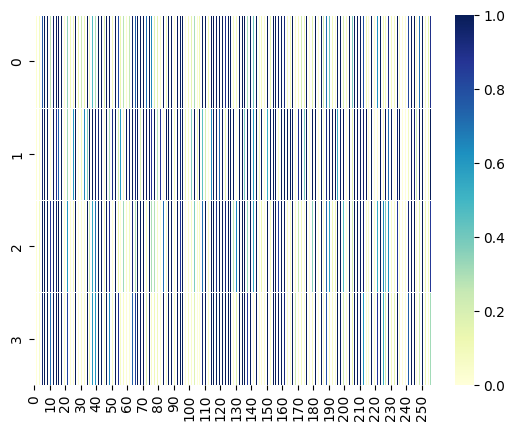

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

type_matrix = np.array([
    v for _, v in results['type'].items()
])
# 创建热力图
sns.heatmap(type_matrix, annot=False, cmap="YlGnBu", linewidths=0.5)

<Axes: >

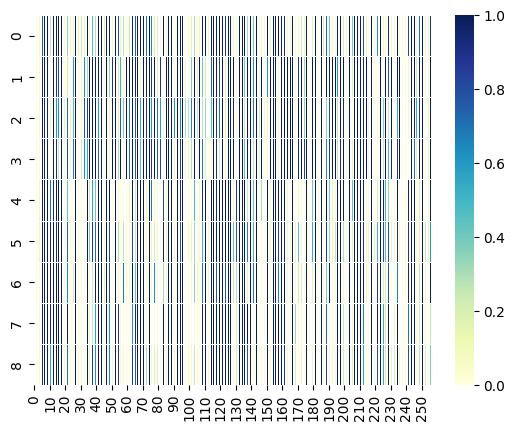

In [36]:
task_matrix = np.array([
    v for _, v in results['tasks'].items()
])
# 创建热力图
sns.heatmap(task_matrix, annot=False, cmap="YlGnBu", linewidths=0.5)

In [37]:
print(task_matrix[-1])

[1.         0.004004   1.         0.05905906 1.         0.92992993
 1.         0.1041041  1.         1.         0.55055055 0.59059059
 1.         0.07407407 0.998999   1.         0.46646647 1.
 1.         0.06306306 0.99499499 0.6966967  0.07707708 0.03903904
 0.98098098 0.01501502 1.         0.94594595 0.02902903 1.
 0.05805806 1.         0.04604605 0.27127127 1.         0.13113113
 0.001001   0.85885886 1.         0.62062062 0.03103103 0.997998
 0.1951952  1.         0.001001   0.03403403 1.         0.58158158
 0.66266266 1.         0.07007007 0.72672673 1.         0.98798799
 0.89389389 0.05505506 1.         0.09409409 1.         0.02602603
 0.99199199 0.03003003 0.01001001 0.85385385 1.         0.76276276
 1.         0.08108108 0.99499499 0.97897898 1.         1.
 0.3003003  1.         1.         0.08408408 0.02102102 0.16716717
 0.996997   0.16216216 1.         0.01401401 0.04804805 0.998999
 0.0960961  0.09309309 1.         0.998999   1.         1.
 0.07007007 0.14914915 1.      